<a href="https://colab.research.google.com/github/Swikriti07/2461862_SwikritiShrestha_Assignment1/blob/main/2461862_SwikritiShrestha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem 1
Basic Data Exploration & Trend Visualization
3.1 Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)
Objective:
Explore the HDI dataset for the latest available year (2022) to practice basic EDA techniques.
Tasks:
Complete all the Following Tasks:
1. Extract Latest Year:
• Identify unique years in the dataset.
• Filter the dataset to include only observations from the year 2022.
• Save the filtered dataframe as hdi 2022 df (used for all subsequent tasks in Problem 1A).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('/content/drive/MyDrive/DataSet/Human_Development_Index_Dataset.csv',encoding='latin1')

last_zimbabwe_index = data[data["country"] == "Zimbabwe"].index.max()

data = data.loc[:last_zimbabwe_index]

#Identify unique years in the dataset.
data['year'].unique()

#Filter the dataset to include only observations from the year 2022.
hdi_2022_df=data[data['year']==2022].copy()


#2. Data Exploration:
• Display the first 10 rows of the 2022 dataset.

In [ ]:
#Display the first 10 rows of the 2022 dataset
hdi_2022_df.head(10)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


#• Count the number of rows and columns.

In [ ]:
#Count the number of rows and columns.
rows,columns=hdi_2022_df.shape
print("Number of rows:",rows)
print("Number of columns:",columns)

Number of rows: 195
Number of columns: 30


#• List all column names and their data types.

In [ ]:
#List all column names and their data types.
hdi_2022_df.dtypes


,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


#3. Missing Values & Data Cleaning:
• Check for missing values in each column and report total counts.

In [ ]:
# Missing values per column
print("Missing values per column:")
print(hdi_2022_df.isnull().sum())

# Total missing values
print("\nTotal missing values:", hdi_2022_df.isnull().sum().sum())


Missing values per column:
Unnamed: 0                    0
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64


#• Inspect dataset for:
– numeric columns stored as text,


In [ ]:
text_cols = hdi_2022_df.select_dtypes(include='object').columns
print("Columns with object type:", text_cols)

Columns with object type: Index(['iso3', 'country'], dtype='object')


#– inconsistent or misspelled country names,

In [ ]:
#– inconsistent or misspelled country names,
hdi_2022_df['country'] = (hdi_2022_df['country'].astype(str).str.strip().str.title())

#– duplicate rows,

In [ ]:
#– duplicate rows
print("No of duplicate rows:",hdi_2022_df.duplicated().sum())

No of duplicate rows: 0


#– special characters (e.g., “–”) representing missing data.

In [ ]:
#Missing or null values
print("\nTotal missing values")
total_nan = hdi_2022_df.isna().sum().sum()
print("Total missing values:", total_nan)


#Dropping missing values
print("\nAfter Dropping missing values")
hdi_2022_df = hdi_2022_df.dropna()
total_nan = hdi_2022_df.isna().sum().sum()
print("Total missing values:", total_nan)




Total missing values
Total missing values: 212

After Dropping missing values
Total missing values: 0


#Apply necessary cleaning steps:
– convert data types where needed,

In [ ]:
numeric_columns = ['hdi','life_expectancy','gross_inc_percap','gender_development']

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')



#– handle missing values (drop or impute; justify your choice).

In [ ]:
hdi_2022_df = hdi_2022_df.dropna(subset=['hdi'])


4. Basic Statistics:
• Compute the mean, median, and standard deviation of HDI for the year 2022.
• Identify the country with the highest HDI in 2022.
• Identify the country with the lowest HDI in 2022.

In [ ]:
#• Compute the mean, median, and standard deviation of HDI for the year 2022.
mean_hdi=hdi_2022_df['hdi'].mean()
median_hdi=hdi_2022_df['hdi'].median()
sd_hdi=hdi_2022_df['hdi'].std()

print("Mean HDI:",mean_hdi)
print("Median HDI:",median_hdi)
print("Standard Deviation HDI:",sd_hdi)

# Identify the country with the highest and lowest HDI in 2022
sorted_hdi = hdi_2022_df.sort_values(by='hdi')

# Lowest HDI
lowest_country = sorted_hdi.iloc[0]['country']
lowest_hdi = sorted_hdi.iloc[0]['hdi']

# Highest HDI
highest_country = sorted_hdi.iloc[-1]['country']
highest_hdi = sorted_hdi.iloc[-1]['hdi']


print("\nHighest HDI")
print(f"Country with highest HDI in 2022: {highest_country} ({highest_hdi})")
print("\nLowest HDI")
print(f"Country with lowest HDI in 2022: {lowest_country} ({lowest_hdi})")



Mean HDI: 0.7331768707482993
Median HDI: 0.76
Standard Deviation HDI: 0.1601509861520783

Highest HDI
Country with highest HDI in 2022: Switzerland (0.967)

Lowest HDI
Country with lowest HDI in 2022: Somalia (0.38)


#5. Filtering and Sorting:
• Filter countries with HDI {"hdi"} greater than 0.800.
• Sort this filtered dataset by Gross National Income (GNI) per Capita {"gross inc percap"} in
descending order.
• Display the top 10 countries.

In [ ]:
# Filter countries with HDI > 0.800
hdi_grt = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]

# Sort by Gross National Income per capita (descending)
hdi_grt = hdi_grt.sort_values(by='gross_inc_percap', ascending=False)

# Display top 10 countries
top10=hdi_grt.head(10)
print(top10[['country','hdi','gross_inc_percap']])


                   country    hdi  gross_inc_percap
4718                 Qatar  0.875       95944.37754
5213             Singapore  0.949       88761.14559
2705               Ireland  0.950       87467.51391
3398            Luxembourg  0.927       78554.23640
6104  United Arab Emirates  0.937       74103.71494
5609           Switzerland  0.967       69432.78669
4322                Norway  0.966       69189.76165
6170         United States  0.927       65564.93798
1550               Denmark  0.952       62018.95694
824      Brunei Darussalam  0.823       59245.63485


#6. Adding HDI Category Column:
• Create a new column HDI Category that classifies each country into one of the four official
Human Development Index groups. The classification should be based on the HDI value for the
year 2022. Use the following categories and thresholds defined by the United Nations Development
Programme (UNDP):

HDI Category HDI Range (hdi)
Low < 0.550
Medium 0.550 – 0.699
High 0.700 – 0.799
Very ≥ 0.800

After creating this new column:
• verify that all countries are classified correctly,
• ensure the updated dataframe includes the new category column.
• Save the final dataframe as HDI category added.csv and include this file in your final
submission.

In [ ]:
def hdi_category(x):
    if x < 0.55:
        return "Low"
    elif x < 0.70:
        return "Medium"
    elif x < 0.80:
        return "High"
    else:
        return "Very High"

hdi_2022_df['HDI Category']=hdi_2022_df['hdi'].apply(hdi_category)
print(hdi_2022_df['HDI Category'].value_counts())
hdi_2022_df.to_csv("HDI_category_added.csv", index=False)
print(hdi_2022_df[['country', 'hdi', 'HDI Category']].head())

HDI Category
Very High    58
High         35
Medium       28
Low          26
Name: count, dtype: int64
         country    hdi HDI Category
32   Afghanistan  0.462          Low
65       Albania  0.789         High
98       Algeria  0.745         High
164       Angola  0.591       Medium
230    Argentina  0.849    Very High


#3.2 Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)
Objective:
Analyze multi-year HDI patterns (2020, 2021, and 2022) to explore temporal changes, regional differences,
and trends across countries.
Tasks:
Complete all the Following Tasks:
1. Data Extraction and Saving:
• Filter the dataset to include only the years 2020, 2021, and 2022.
• Save the filtered dataset as HDI problem1B.csv.
• Use this cleaned dataset for all subsequent tasks in Problem 1B.

In [ ]:
# List of years to include
years = [2020, 2021, 2022]

# Filter the dataset
hdi_2020_2022_df = data[data['year'].isin(years)]

hdi_2020_2022_df.to_csv('HDI_problem1B.csv',index=False)
hdi_2020_2022_df.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
30,31,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
31,32,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
63,64,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,...,0.978,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704
64,65,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,...,0.981,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865


#2. Data Cleaning:
• Check for missing values in the following essential columns:
– hdi
– country
– year
• Identify and address the following issues:
– missing or null values,
• Apply and justify cleaning steps, including:
– handling missing values (dropping or imputing),

In [ ]:
#Check for missing values in the following essential columns: – hdi – country – year
missing_values = hdi_2020_2022_df[['hdi', 'country', 'year']].isnull().sum()
print("Missing Values per Column:")
print(missing_values)


# Drop rows with missing essential values
hdi_2020_2022_df = hdi_2020_2022_df.dropna(subset=['hdi','country','year'])

#Missing or null values
print("\nTotal missing values")
total_nan = hdi_2020_2022_df.isna().sum().sum()
print("Total missing values:", total_nan)


#Dropping missing values
print("\nAfter Dropping missing values")
hdi_2020_2022_df = hdi_2020_2022_df.dropna()
total_nan = hdi_2020_2022_df.isna().sum().sum()
print("Total missing values:", total_nan)





Missing Values per Column:
hdi        8
country    0
year       0
dtype: int64

Total missing values
Total missing values: 534

After Dropping missing values
Total missing values: 0


#– inconsistent or misspelled country names,
– ensuring consistent naming conventions for countries and years.

In [ ]:
#– inconsistent or misspelled country names,
print(hdi_2020_2022_df['country'].value_counts())

#ensuring consistent naming conventions for countries.
hdi_2020_2022_df['country'] = hdi_2020_2022_df['country'].str.strip().str.title()


# ensuring consistent naming conventions for years.
hdi_2020_2022_df['year'] = pd.to_numeric(data['year'], errors='coerce').astype('Int64')


country
Afghanistan                           3
Albania                               3
Algeria                               3
Angola                                3
Argentina                             3
                                     ..
Venezuela (Bolivarian Republic of)    3
Zambia                                3
Yemen                                 3
Zimbabwe                              3
Somalia                               1
Name: count, Length: 147, dtype: int64


#– duplicate rows,– removing duplicate entries,

In [ ]:
# Check duplicates
print("Total duplicates:", hdi_2020_2022_df.duplicated().sum())

Total duplicates: 0


#– numeric columns stored as text or containing non-numeric symbols (e.g., “–”).
– converting data types appropriately,

In [ ]:
numeric_columns = ['hdi','life_expectancy','gross_inc_percap','gender_development']
hdi_2020_2022_df[numeric_columns] = hdi_2020_2022_df[numeric_columns].replace("–", np.nan)

# Convert columns to numeric type
for col in numeric_columns:
    hdi_2020_2022_df[col] = pd.to_numeric(data[col], errors='coerce')

print("Data types after conversion:")
print(hdi_2020_2022_df[numeric_columns].dtypes)


Data types after conversion:
hdi                   float64
life_expectancy       float64
gross_inc_percap      float64
gender_development    float64
dtype: object


#3. Visualization Tasks:
• A. Line Chart — HDI Trend (Country-Level):
– Select any five countries (or five countries from a region of your choice).
– Plot HDI values for each country across the years 2020, 2021, and 2022.
– Ensure the chart includes appropriate axis labels, a legend, and an informative caption.

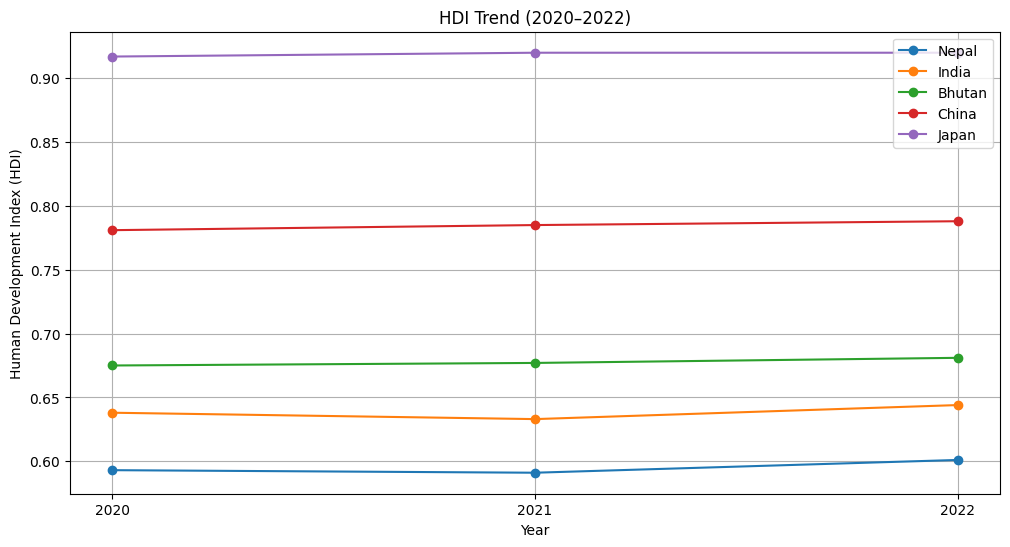

In [ ]:
import matplotlib.pyplot as plt

countries = ['Nepal', 'India', 'Bhutan', 'China', 'Japan']
plt.figure(figsize=(12, 6))

for c in countries:
    temp = hdi_2020_2022_df[hdi_2020_2022_df['country'] == c]
    plt.plot(temp['year'], temp['hdi'], marker='o', label=c)

plt.xlabel("Year")
plt.ylabel("Human Development Index (HDI)")
plt.grid(True)
plt.title("HDI Trend (2020–2022)")
plt.xticks([2020, 2021, 2022])
plt.legend()
plt.savefig("Line Chart-HDI Trend.png")
plt.show()


#• B. Generate Visualizations:
– Bar Chart: Average HDI by Region (2020–2022)
∗ Group the dataset by Region and Year.
∗ Compute the mean HDI for each region-year pair.
∗ Plot a bar chart comparing average HDI across regions for each year.
∗ Label axes clearly and include a descriptive title.

In [ ]:
region_map = {

    # East Asia & Pacific
    "Australia": "East Asia & Pacific",
    "Brunei Darussalam": "East Asia & Pacific",
    "Cambodia": "East Asia & Pacific",
    "China": "East Asia & Pacific",
    "Fiji": "East Asia & Pacific",
    "Indonesia": "East Asia & Pacific",
    "Japan": "East Asia & Pacific",
    "Kiribati": "East Asia & Pacific",
    "Korea (Republic Of)": "East Asia & Pacific",
    "Lao People'S Democratic Republic": "East Asia & Pacific",
    "Malaysia": "East Asia & Pacific",
    "Marshall Islands": "East Asia & Pacific",
    "Micronesia, Fed. Sts.": "East Asia & Pacific",
    "Mongolia": "East Asia & Pacific",
    "Myanmar": "East Asia & Pacific",
    "Nauru": "East Asia & Pacific",
    "New Zealand": "East Asia & Pacific",
    "Palau": "East Asia & Pacific",
    "Papua New Guinea": "East Asia & Pacific",
    "Philippines": "East Asia & Pacific",
    "Samoa": "East Asia & Pacific",
    "Singapore": "East Asia & Pacific",
    "Solomon Islands": "East Asia & Pacific",
    "Thailand": "East Asia & Pacific",
    "Timor-Leste": "East Asia & Pacific",
    "Tonga": "East Asia & Pacific",
    "Tuvalu": "East Asia & Pacific",
    "Vanuatu": "East Asia & Pacific",
    "Viet Nam": "East Asia & Pacific",

    # Europe & Central Asia
    "Albania": "Europe & Central Asia",
    "Armenia": "Europe & Central Asia",
    "Austria": "Europe & Central Asia",
    "Azerbaijan": "Europe & Central Asia",
    "Belarus": "Europe & Central Asia",
    "Belgium": "Europe & Central Asia",
    "Bosnia And Herzegovina": "Europe & Central Asia",
    "Bulgaria": "Europe & Central Asia",
    "Croatia": "Europe & Central Asia",
    "Cyprus": "Europe & Central Asia",
    "Czechia": "Europe & Central Asia",
    "Denmark": "Europe & Central Asia",
    "Estonia": "Europe & Central Asia",
    "Finland": "Europe & Central Asia",
    "France": "Europe & Central Asia",
    "Georgia": "Europe & Central Asia",
    "Germany": "Europe & Central Asia",
    "Greece": "Europe & Central Asia",
    "Hungary": "Europe & Central Asia",
    "Iceland": "Europe & Central Asia",
    "Ireland": "Europe & Central Asia",
    "Italy": "Europe & Central Asia",
    "Kazakhstan": "Europe & Central Asia",
    "Kyrgyzstan": "Europe & Central Asia",
    "Latvia": "Europe & Central Asia",
    "Lithuania": "Europe & Central Asia",
    "Luxembourg": "Europe & Central Asia",
    "Malta": "Europe & Central Asia",
    "Moldova (Republic Of)": "Europe & Central Asia",
    "Netherlands": "Europe & Central Asia",
    "North Macedonia": "Europe & Central Asia",
    "Norway": "Europe & Central Asia",
    "Poland": "Europe & Central Asia",
    "Portugal": "Europe & Central Asia",
    "Romania": "Europe & Central Asia",
    "Russian Federation": "Europe & Central Asia",
    "Serbia": "Europe & Central Asia",
    "Slovak Republic": "Europe & Central Asia",
    "Slovenia": "Europe & Central Asia",
    "Spain": "Europe & Central Asia",
    "Sweden": "Europe & Central Asia",
    "Switzerland": "Europe & Central Asia",
    "Türkiye": "Europe & Central Asia",
    "Tajikistan": "Europe & Central Asia",
    "Ukraine": "Europe & Central Asia",
    "United Kingdom": "Europe & Central Asia",
    "Uzbekistan": "Europe & Central Asia",

    # Latin America & Caribbean
    "Argentina": "Latin America & Caribbean",
    "Bahamas": "Latin America & Caribbean",
    "Barbados": "Latin America & Caribbean",
    "Belize": "Latin America & Caribbean",
    "Bolivia (Plurinational State Of)": "Latin America & Caribbean",
    "Brazil": "Latin America & Caribbean",
    "Chile": "Latin America & Caribbean",
    "Colombia": "Latin America & Caribbean",
    "Costa Rica": "Latin America & Caribbean",
    "Cuba": "Latin America & Caribbean",
    "Dominican Republic": "Latin America & Caribbean",
    "Ecuador": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean",
    "Guyana": "Latin America & Caribbean",
    "Haiti": "Latin America & Caribbean",
    "Honduras": "Latin America & Caribbean",
    "Jamaica": "Latin America & Caribbean",
    "Mexico": "Latin America & Caribbean",
    "Nicaragua": "Latin America & Caribbean",
    "Panama": "Latin America & Caribbean",
    "Paraguay": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean",
    "Suriname": "Latin America & Caribbean",
    "Trinidad and Tobago": "Latin America & Caribbean",
    "Uruguay": "Latin America & Caribbean",
    "Venezuela (Bolivarian Republic Of)": "Latin America & Caribbean",

    # Middle East & North Africa
    "Algeria": "Middle East & North Africa",
    "Bahrain": "Middle East & North Africa",
    "Egypt": "Middle East & North Africa",
    "Iran (Islamic Republic Of)": "Middle East & North Africa",
    "Iraq": "Middle East & North Africa",
    "Israel": "Middle East & North Africa",
    "Jordan": "Middle East & North Africa",
    "Kuwait": "Middle East & North Africa",
    "Lebanon": "Middle East & North Africa",
    "Libya": "Middle East & North Africa",
    "Morocco": "Middle East & North Africa",
    "Oman": "Middle East & North Africa",
    "Qatar": "Middle East & North Africa",
    "Saudi Arabia": "Middle East & North Africa",
    "Tunisia": "Middle East & North Africa",
    "United Arab Emirates": "Middle East & North Africa",
    "Yemen": "Middle East & North Africa",

    # North America
    "Canada": "North America",
    "United States": "North America",

    # South Asia
    "Afghanistan": "South Asia",
    "Bangladesh": "South Asia",
    "Bhutan": "South Asia",
    "India": "South Asia",
    "Maldives": "South Asia",
    "Nepal": "South Asia",
    "Pakistan": "South Asia",
    "Sri Lanka": "South Asia",

    # Sub-Saharan Africa
    "Angola": "Sub-Saharan Africa",
    "Benin": "Sub-Saharan Africa",
    "Botswana": "Sub-Saharan Africa",
    "Burkina Faso": "Sub-Saharan Africa",
    "Burundi": "Sub-Saharan Africa",
    "Cameroon": "Sub-Saharan Africa",
    "Central African Republic": "Sub-Saharan Africa",
    "Chad": "Sub-Saharan Africa",
    "Congo (Democratic Republic Of The)": "Sub-Saharan Africa",
    "Congo": "Sub-Saharan Africa",
    "Côte d’Ivoire": "Sub-Saharan Africa",
    "Ethiopia": "Sub-Saharan Africa",
    "Gabon": "Sub-Saharan Africa",
    "Gambia": "Sub-Saharan Africa",
    "Ghana": "Sub-Saharan Africa",
    "Guinea": "Sub-Saharan Africa",
    "Kenya": "Sub-Saharan Africa",
    "Liberia": "Sub-Saharan Africa",
    "Madagascar": "Sub-Saharan Africa",
    "Malawi": "Sub-Saharan Africa",
    "Mauritania": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa",
    "Mozambique": "Sub-Saharan Africa",
    "Namibia": "Sub-Saharan Africa",
    "Niger": "Sub-Saharan Africa",
    "Nigeria": "Sub-Saharan Africa",
    "Rwanda": "Sub-Saharan Africa",
    "Senegal": "Sub-Saharan Africa",
    "Slovakia":"Sub-Saharan Africa",
    "Sierra Leone": "Sub-Saharan Africa",
    "Sudan": "Sub-Saharan Africa",
    "South Africa": "Sub-Saharan Africa",
    "Somalia": "Sub-Saharan Africa",
    "South Sudan": "Sub-Saharan Africa",
    "Tanzania (United Republic Of)": "Sub-Saharan Africa",
    "Togo": "Sub-Saharan Africa",
    "Tanzania": "Sub-Saharan Africa",
    "Uganda": "Sub-Saharan Africa",
    "Zambia": "Sub-Saharan Africa",
    "Zimbabwe": "Sub-Saharan Africa"
}
hdi_2020_2022_df['Region'] = hdi_2020_2022_df['country'].map(region_map)
hdi_2020_2022_df.head()


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,Region
30,31,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554,South Asia
31,32,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351,South Asia
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809,South Asia
63,64,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,...,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704,Europe & Central Asia
64,65,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,...,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865,Europe & Central Asia


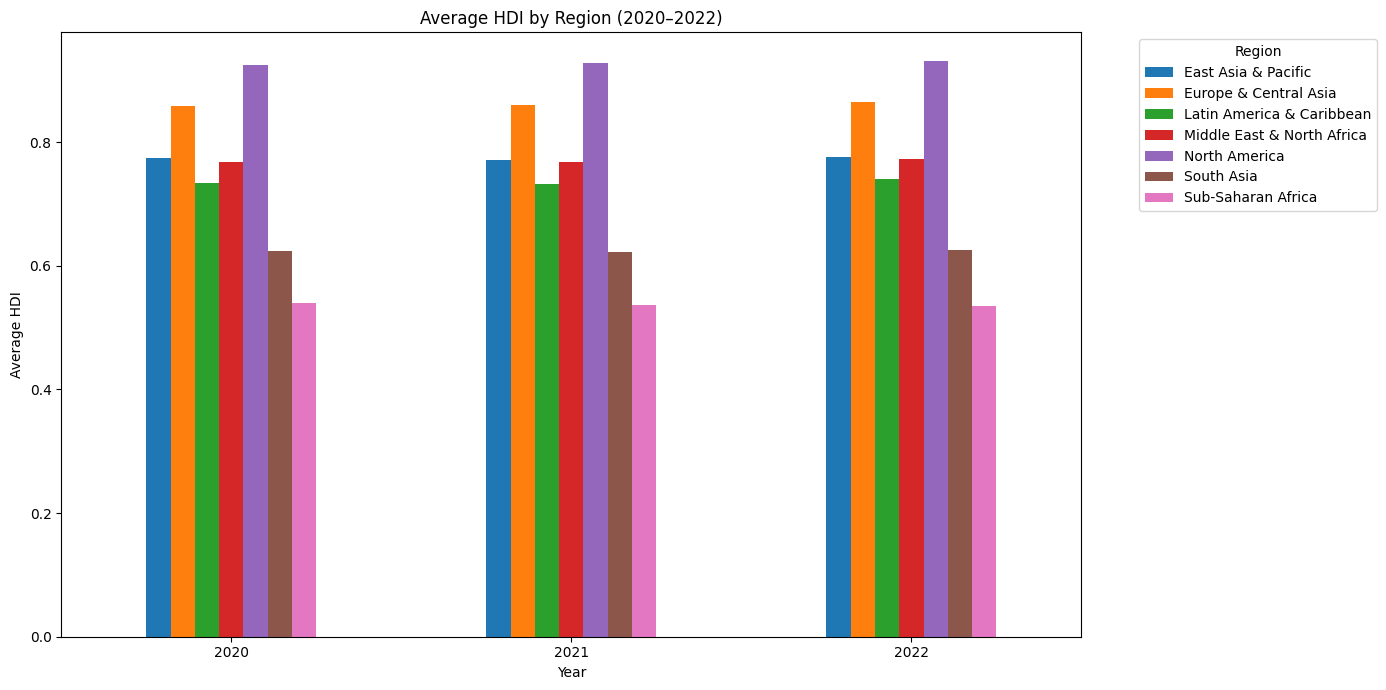

In [ ]:
avg_region_year = hdi_2020_2022_df.groupby(['year', 'Region'])['hdi'].mean().unstack()

# Plot grouped bar chart
avg_region_year.plot(kind='bar', figsize=(14,7))
plt.ylabel("Average HDI")
plt.xlabel("Year")
plt.title("Average HDI by Region (2020–2022)")
plt.xticks(rotation=0)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1))  # place legend outside
plt.tight_layout()
plt.savefig("Bar Chart: Average HDI by Region.png")
plt.show()



#– Box Plot: HDI Distribution for 2020, 2021, and 2022
∗ Filter the dataset for the years 2020, 2021, and 2022.
∗ Create a box plot showing HDI spread for each of the three years.
∗ Include titles and axis labels.
∗ Comment briefly on distribution differences.

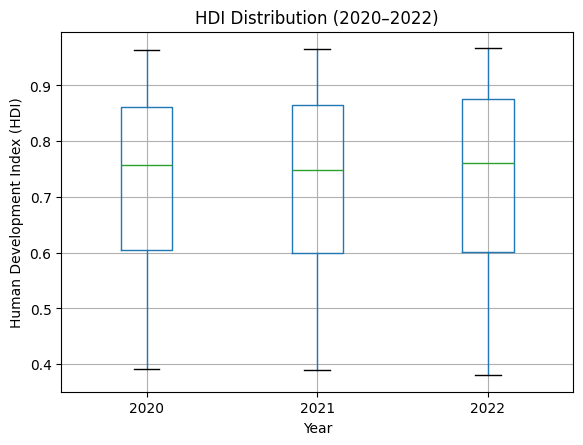

In [ ]:
hdi_2020_2022_df.boxplot(column='hdi', by='year')
plt.title("HDI Distribution (2020–2022)")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Human Development Index (HDI)")
plt.savefig("Box Plot: HDI Distribution.png")
plt.show()


#– Scatter Plot: HDI vs. GNI per Capita
∗ Check if the dataset contains a column for GNI per Capita.
∗ If available:
· Create a scatter plot using HDI as the dependent variable.
· Use GNI per Capita on the x-axis.
· Add a regression line (optional).
∗ If the variable is missing, write:
"GNI per Capita variable not available in the dataset."

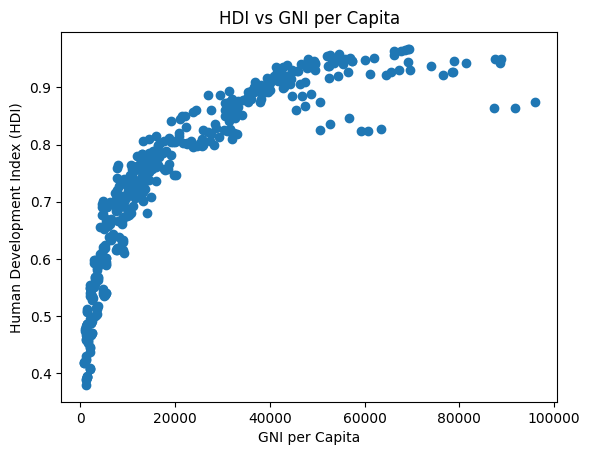

In [ ]:
if 'gross_inc_percap' in hdi_2020_2022_df.columns:
  plt.scatter(hdi_2020_2022_df['gross_inc_percap'],hdi_2020_2022_df['hdi'])
  plt.xlabel("GNI per Capita")
  plt.ylabel("Human Development Index (HDI)")
  plt.title("HDI vs GNI per Capita")
  plt.savefig("HDI_vs_GNI_per_Capita.png")
  plt.show()
else:
    print("GNI per Capita variable not available in the dataset.")


#4. Short Analysis Questions:
#• Which countries show the greatest improvement in HDI from 2020 to 2022?
Ans: Countries such as ( Azerbaijan, Ecuador) and many other countries show the greatest improvement inHDI from 2020 to 2022.


In [ ]:
hdi_2020 = hdi_2020_2022_df[hdi_2020_2022_df['year'] == 2020]
hdi_2022 = hdi_2020_2022_df[hdi_2020_2022_df['year'] == 2022]
hdi_change = hdi_2020[['country','hdi']].merge(
    hdi_2022[['country','hdi']],
    on='country',
    suffixes=('_2020', '_2022')
)
hdi_change['hdi_improvement'] = hdi_change['hdi_2022'] - hdi_change['hdi_2020']

top_improvement = hdi_change.sort_values(
    by='hdi_improvement',
    ascending=False
)

print(top_improvement.head(10))


            country  hdi_2020  hdi_2022  hdi_improvement
8        Azerbaijan     0.722     0.760            0.038
40          Ecuador     0.734     0.765            0.031
87           Mexico     0.757     0.781            0.024
128      Tajikistan     0.656     0.679            0.023
9           Bahamas     0.798     0.820            0.022
72           Kuwait     0.826     0.847            0.021
133         Türkiye     0.835     0.855            0.020
137  United Kingdom     0.920     0.940            0.020
34          Croatia     0.860     0.878            0.018
5           Armenia     0.769     0.786            0.017


#• Did any countries experience a decline in HDI? Provide possible reasons.
Ans: Counties such as(Timor-Leste, Ukraine, Afghansitan) and many more countires experience a decline in HDI.
Possible reasons:
1.Due to poor life expectany,
2.Due to low gross income per capital,
3.Due to poor education


In [ ]:
hdi_2020 = hdi_2020_2022_df[hdi_2020_2022_df['year'] == 2020]
hdi_2022 = hdi_2020_2022_df[hdi_2020_2022_df['year'] == 2022]
hdi_change = hdi_2020[['country','hdi']].merge(
    hdi_2022[['country','hdi']],
    on='country',
    suffixes=('_2020', '_2022')
)
hdi_change['hdi_decline'] = hdi_change['hdi_2022'] - hdi_change['hdi_2020']

top_improvement = hdi_change.sort_values(
    by='hdi_decline',
    ascending=True
)

print(top_improvement.head(10))

          country  hdi_2020  hdi_2022  hdi_decline
135       Ukraine     0.762     0.734       -0.028
0     Afghanistan     0.488     0.462       -0.026
93        Namibia     0.634     0.610       -0.024
76        Lebanon     0.742     0.723       -0.019
106      Paraguay     0.742     0.731       -0.011
47          Gabon     0.704     0.693       -0.011
53      Guatemala     0.638     0.629       -0.009
22   Burkina Faso     0.446     0.438       -0.008
92        Myanmar     0.615     0.608       -0.007
91     Mozambique     0.467     0.461       -0.006


• Which region has the highest and lowest average HDI across these three years?

Ans: North America has highest average HDI whereas Sub-Saharan Africa has the lowest average HDI.

In [ ]:
avg_hdi_region = hdi_2020_2022_df.groupby("Region")["hdi"].mean()

highest_region = avg_hdi_region.idxmax()
lowest_region = avg_hdi_region.idxmin()

print("Average HDI by Region (2020–2022):")
print(avg_hdi_region.round(3))

print("\nRegion with highest average HDI:", highest_region)
print("Region with lowest average HDI:", lowest_region)


Average HDI by Region (2020–2022):
Region
East Asia & Pacific           0.773
Europe & Central Asia         0.861
Latin America & Caribbean     0.735
Middle East & North Africa    0.770
North America                 0.928
South Asia                    0.624
Sub-Saharan Africa            0.537
Name: hdi, dtype: float64

Region with highest average HDI: North America
Region with lowest average HDI: Sub-Saharan Africa


• Discuss how global events (e.g., the COVID-19 pandemic) may have affected HDI trends during
this period.

Ans: Global events like COVID-19 pandemic has affected HDI trends during this periods. The pandemic has affected the health system and caused economic slowdowns that have impacted the HDI Trends.

#Problem 2
Advanced HDI Exploration
Objective:

Perform advanced analysis of HDI data, focusing on South Asian countries, composite metrics, outlier detec-
tion, metric relationships, and gap analysis.


#Tasks:
Complete all the following tasks:
1. Create South Asia Subset:
• Define the list of South Asian countries: ["Afghanistan", "Bangladesh", "Bhutan", "India",
"Maldives", "Nepal", "Pakistan", "Sri Lanka"].
• Filter the HDI dataset to include only these countries.
• Save the filtered dataset as HDI SouthAsia.csv and include this file in the final submission.

In [ ]:
south_Asian=["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]
hdi_south_asia = data[data['country'].isin(south_Asian)].copy()
hdi_south_asia.to_csv("HDI_SouthAsia.csv", index=False)

2. Composite Development Score:
• Create a new metric called Composite Score using the formula:

Composite Score = 0.30 × Life Expectancy Index + 0.30 × GNI per Capita Index}
Here: Life Expectancy Index → "life expectancy" and GNI per Capita Index → "gross inc percap"
• Rank South Asian countries based on Composite Score.
• Plot the top 5 countries in a horizontal bar chart.
• Compare the ranking of countries by Composite Score with their HDI ranking and discuss any
differences.


Top 5 South Asian Countries by Composite Score in 1990s:
country
Maldives     3024.723773
Sri Lanka    1472.435534
Pakistan      965.657045
Bhutan        909.574292
India         636.883028
Name: Composite_Score, dtype: float64

Top 5 South Asian Countries by HDI in 1990s:
country
Sri Lanka     0.6670
Maldives      0.6058
India         0.4567
Bangladesh    0.4370
Nepal         0.4261
Name: hdi, dtype: float64


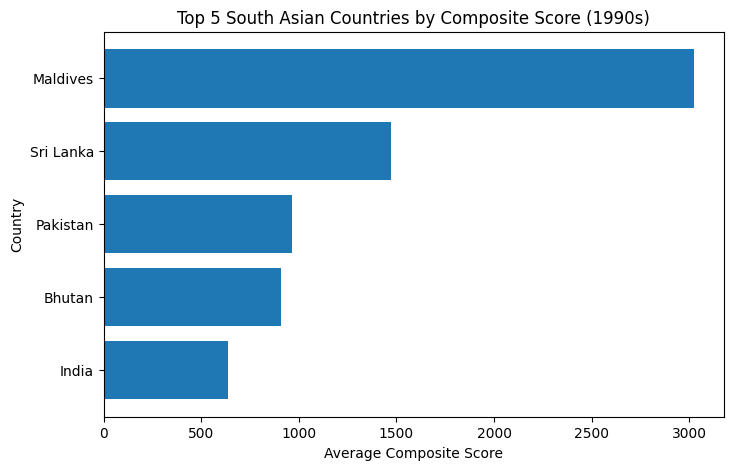


Top 5 South Asian Countries by Composite Score in 2000s:
country
Maldives     4273.809348
Sri Lanka    2137.544010
Bhutan       1626.280127
Pakistan     1112.312573
India         965.673484
Name: Composite_Score, dtype: float64

Top 5 South Asian Countries by HDI in 2000s:
country
Sri Lanka     0.7029
Maldives      0.6588
India         0.5265
Bangladesh    0.5193
Nepal         0.4903
Name: hdi, dtype: float64


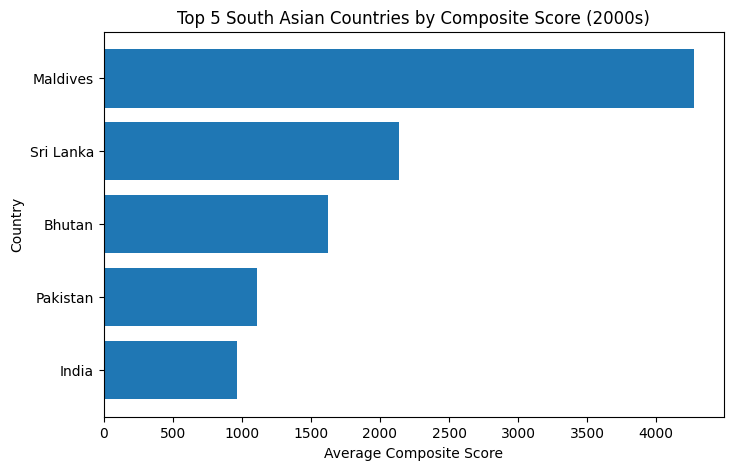


Top 5 South Asian Countries by Composite Score in 2010s:
country
Maldives      4962.203432
Sri Lanka     3518.317313
Bhutan        2733.270564
India         1602.444237
Bangladesh    1391.573452
Name: Composite_Score, dtype: float64

Top 5 South Asian Countries by HDI in 2010s:
country
Sri Lanka     0.7576
Maldives      0.7241
Bhutan        0.6216
India         0.6122
Bangladesh    0.5981
Name: hdi, dtype: float64


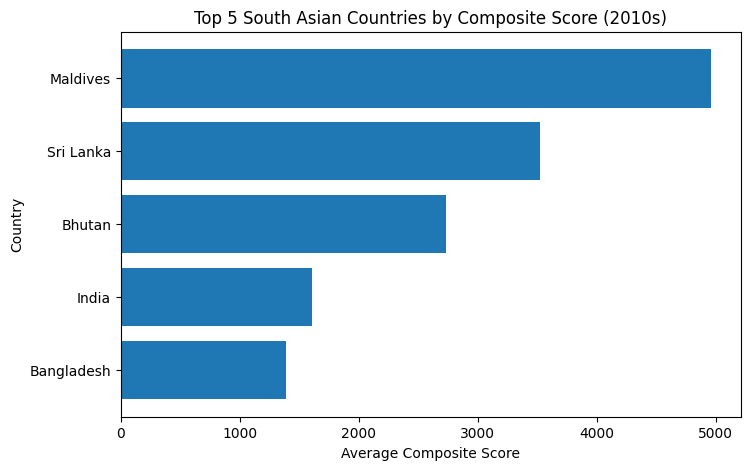


Top 5 South Asian Countries by Composite Score in 2020s:
country
Maldives      4827.657597
Sri Lanka     3767.752918
Bhutan        3097.787317
India         1978.776712
Bangladesh    1877.251264
Name: Composite_Score, dtype: float64

Top 5 South Asian Countries by HDI in 2020s:
country
Sri Lanka     0.780000
Maldives      0.750667
Bhutan        0.677667
Bangladesh    0.663000
India         0.638333
Name: hdi, dtype: float64


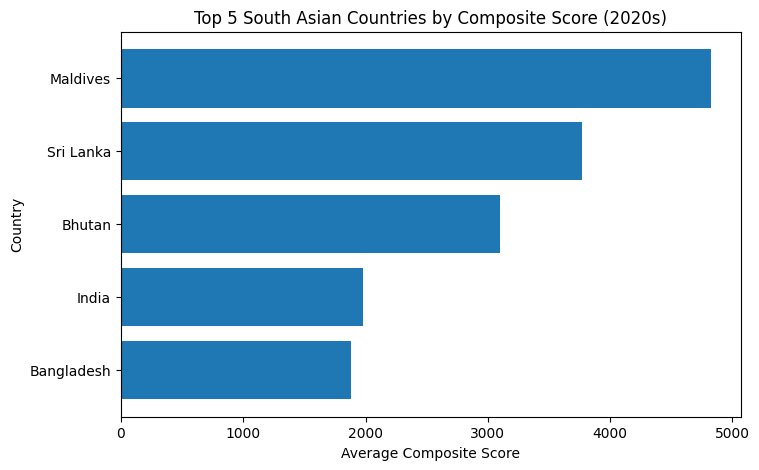

In [ ]:

hdi_south_asia["Composite_Score"] = (
    0.30 * hdi_south_asia["life_expectancy"] +
    0.30 * hdi_south_asia["gross_inc_percap"]
)

# Assign decades
def assign_decade(year):
    if 1990 <= year <= 1999:
        return "1990s"
    elif 2000 <= year <= 2009:
        return "2000s"
    elif 2010 <= year <= 2019:
        return "2010s"
    elif 2020 <= year <= 2022:
        return "2020s"
    else:
        return "Other"

hdi_south_asia["Decade"] = hdi_south_asia["year"].apply(assign_decade)

decades = hdi_south_asia["Decade"].unique()
for decade in decades:
    df_decade = hdi_south_asia[hdi_south_asia["Decade"] == decade]

    avg_composite = df_decade.groupby("country")["Composite_Score"].mean().sort_values(ascending=False)
    avg_hdi = df_decade.groupby("country")["hdi"].mean().sort_values(ascending=False)

    print(f"\nTop 5 South Asian Countries by Composite Score in {decade}:")
    print(avg_composite.head(5))

    print(f"\nTop 5 South Asian Countries by HDI in {decade}:")
    print(avg_hdi.head(5))

    top5 = avg_composite.head(5)
    plt.figure(figsize=(8,5))
    plt.barh(top5.index, top5.values)
    plt.xlabel("Average Composite Score")
    plt.ylabel("Country")
    plt.title(f"Top 5 South Asian Countries by Composite Score ({decade})")
    plt.gca().invert_yaxis()
    plt.savefig(f"Top 5 South Asian Countries by Composite Score ({decade}).png")
    plt.show()


In [ ]:
#Compare the ranking of countries by Composite Score with their HDI ranking and discuss any differences
hdi_rank = hdi_south_asia.groupby("country")["hdi"].mean().sort_values(ascending=False)

print("HDI Ranking:")
print(hdi_rank)

print("\nComposite Score Ranking:")
print(avg_composite)


HDI Ranking:
country
Sri Lanka      0.715606
Maldives       0.682500
Bhutan         0.634538
India          0.541485
Bangladesh     0.531303
Nepal          0.504242
Pakistan       0.472545
Afghanistan    0.401030
Name: hdi, dtype: float64

Composite Score Ranking:
country
Maldives       4827.657597
Sri Lanka      3767.752918
Bhutan         3097.787317
India          1978.776712
Bangladesh     1877.251264
Pakistan       1565.030032
Nepal          1191.338108
Afghanistan     504.358088
Name: Composite_Score, dtype: float64


3. Outlier Detection:
• Detect outliers in HDI and GNI per Capita using the 1.5 × IQR rule.
• Create a scatter plot of GNI per Capita vs HDI, highlighting the outliers in a different color.
• Discuss why the identified countries stand out as outliers.

In [ ]:
#• Detect outliers in HDI and GNI per Capita using the 1.5 × IQR rule.
print("\nHDI OUTLIER")
Q1_hdi=hdi_south_asia['hdi'].quantile(0.25)
Q3_hdi=hdi_south_asia['hdi'].quantile(0.75)
IQR_hdi=Q3_hdi-Q1_hdi
lower_outlier_hdi=Q1_hdi-1.5*IQR_hdi
upper_outlier_hdi=Q3_hdi+1.5*IQR_hdi
print("Lower Outlier:",lower_outlier_hdi)
print("Upper Outlier:",upper_outlier_hdi)
hdi_outliers = hdi_south_asia[(hdi_south_asia['hdi'] < lower_outlier_hdi) |(hdi_south_asia['hdi'] > upper_outlier_hdi)]
print(hdi_outliers[['country', 'hdi']])
#GNI
print("\nGNI OUTLIER")
Q1_GNI=hdi_south_asia['gross_inc_percap'].quantile(0.25)
Q3_GNI=hdi_south_asia['gross_inc_percap'].quantile(0.75)
IQR_GNI=Q3_GNI-Q1_GNI
lower_outlier_GNI=Q1_GNI-1.5*IQR_GNI
upper_outlier_GNI=Q3_GNI+1.5*IQR_GNI
print("Lower Outlier:",lower_outlier_GNI)
print("Upper Outlier:",upper_outlier_GNI)
GNI_outliers = hdi_south_asia[(hdi_south_asia['gross_inc_percap'] < lower_outlier_GNI) |(hdi_south_asia['gross_inc_percap'] > upper_outlier_GNI)]
print(GNI_outliers[['country', 'gross_inc_percap']])




HDI OUTLIER
Lower Outlier: 0.1805000000000001
Upper Outlier: 0.9244999999999999
Empty DataFrame
Columns: [country, hdi]
Index: []

GNI OUTLIER
Lower Outlier: -4284.548474000001
Upper Outlier: 13386.135914000002
        country  gross_inc_percap
3511   Maldives       14543.14634
3512   Maldives       15287.20714
3514   Maldives       16391.40757
3515   Maldives       14162.42816
3516   Maldives       15423.81910
3517   Maldives       14050.92438
3518   Maldives       14363.23615
3519   Maldives       15300.31364
3520   Maldives       15355.44089
3521   Maldives       15648.36655
3522   Maldives       16410.16419
3523   Maldives       16414.93039
3524   Maldives       16911.45422
3525   Maldives       17474.64201
3526   Maldives       18055.72465
3527   Maldives       18679.92536
3529   Maldives       16857.60546
3530   Maldives       18846.79219
5473  Sri Lanka       13405.80369


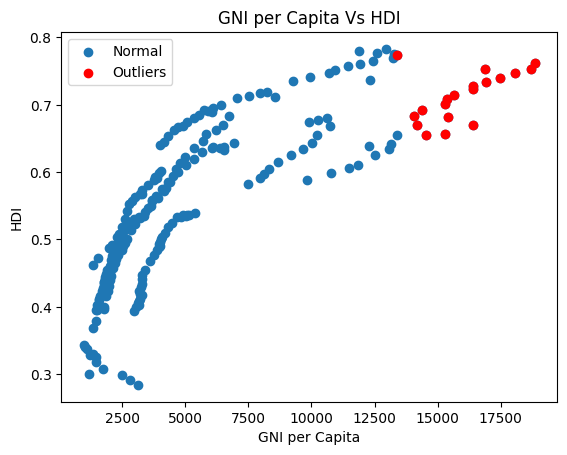

In [ ]:
#• Create a scatter plot of GNI per Capita vs HDI, highlighting the outliers in a different color.
plt.scatter(hdi_south_asia["gross_inc_percap"], hdi_south_asia["hdi"], label="Normal")
plt.scatter(GNI_outliers["gross_inc_percap"],GNI_outliers["hdi"], color="red", label="Outliers")
plt.legend()
plt.title("GNI per Capita Vs HDI")
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.savefig("GNI per Capita Vs HDI.png")
plt.show()

4. Exploring Metric Relationships:
• Select two HDI components (e.g., Gender Development Index {"gender development"} and Life
Expectancy Index {"life expectancy"}).
• Compute Pearson correlation of each metric with HDI.
• Create scatter plots with trendlines to visualize the relationships.
• Discuss:
– Which metric is most strongly related to HDI and shows the weakest relationship with HDI.

In [ ]:
#Correlation between HDI and Gender Development
corr_gender = hdi_south_asia['hdi'].corr(hdi_south_asia['gender_development'])
print("Correlation between HDI and Gender Development:", corr_gender)

#Correlation between HDI and Life Expectancy
corr_life = hdi_south_asia['hdi'].corr(hdi_south_asia['life_expectancy'])
print("Correlation between HDI and Life Expectancy:", corr_life)


Correlation between HDI and Gender Development: 0.8656210050127539
Correlation between HDI and Life Expectancy: 0.9587610559043978


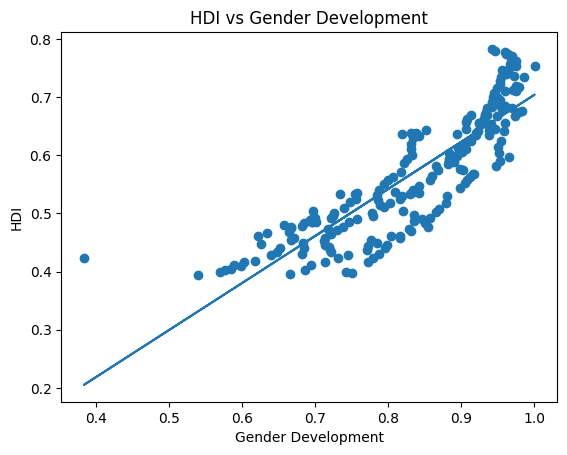

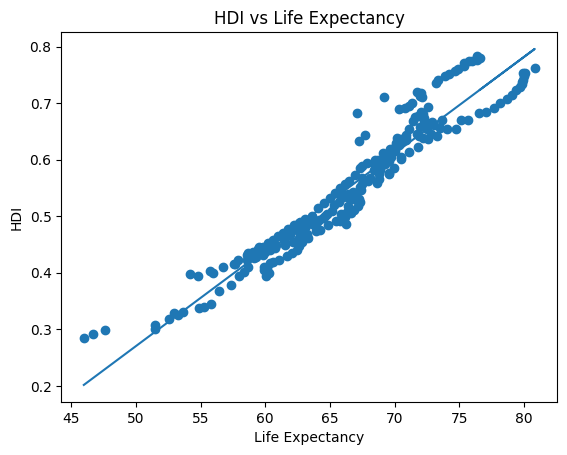

In [ ]:
metrics = ['gender_development', 'life_expectancy']

for metric in metrics:
    data = hdi_south_asia[['hdi', metric]].dropna()

    plt.figure()
    plt.scatter(data[metric], data['hdi'])

    m, b = np.polyfit(data[metric], data['hdi'], 1)
    plt.plot(data[metric], m * data[metric] + b)

    plt.xlabel(metric.replace('_', ' ').title())
    plt.ylabel('HDI')
    plt.title('HDI vs ' + metric.replace('_', ' ').title())
    plt.savefig(f"HDI_vs_{metric}.png")
    plt.show()



#• Discuss: – Which metric is most strongly related to HDI and shows the weakest relationship with HDI.
Ans: Life Expectancy is most strongly related to HDI and Gender Development shows the weakear relation with HDI.

#5. Gap Analysis:
• Create a new metric:

GNI HDI Gap = "gross inc percap" − "hdi"
• Rank South Asian countries by GNI HDI Gap in descending and ascending order.
• Plot the top 3 positive gaps and top 3 negative gaps.
• Discuss the implications of the gap, e.g., cases where GNI is high but HDI is lower than expected.

In [ ]:
# Create a new metric: GNI HDI Gap = "gross inc percap" − "hdi"
hdi_south_asia_mean = hdi_south_asia.groupby("country")[["gross_inc_percap", "hdi"]].mean()
hdi_south_asia_mean['GNI_HDI_GAP'] = hdi_south_asia_mean['gross_inc_percap'] - hdi_south_asia_mean['hdi']

# Rank South Asian countries by GNI HDI Gap in descending order
gap_desc = hdi_south_asia_mean.sort_values(by='GNI_HDI_GAP', ascending=False).reset_index()
print("\nGap in Descending Order")
print(gap_desc[['country','GNI_HDI_GAP']])

# Rank South Asian countries by GNI HDI Gap in ascending order
gap_asc = hdi_south_asia_mean.sort_values(by='GNI_HDI_GAP', ascending=True).reset_index()
print("\nGap in Ascending Order")
print(gap_asc[['country','GNI_HDI_GAP']])



Gap in Descending Order
       country   GNI_HDI_GAP
0     Maldives  13772.688785
1    Sri Lanka   8268.373527
2       Bhutan   6194.936904
3     Pakistan   3883.813530
4        India   3771.381346
5   Bangladesh   3408.490410
6        Nepal   2532.443971
7  Afghanistan   1793.487770

Gap in Ascending Order
       country   GNI_HDI_GAP
0  Afghanistan   1793.487770
1        Nepal   2532.443971
2   Bangladesh   3408.490410
3        India   3771.381346
4     Pakistan   3883.813530
5       Bhutan   6194.936904
6    Sri Lanka   8268.373527
7     Maldives  13772.688785


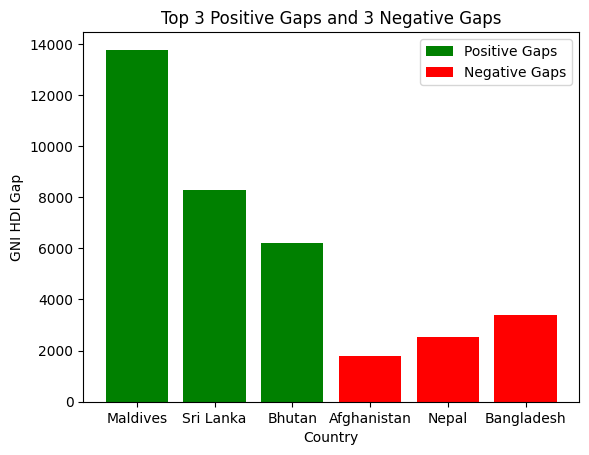

In [ ]:
#top 3 positive gaps and top 3 negative gaps
positive_gap = gap_desc.head(3)
negative_gap = gap_asc.head(3)
plt.bar(positive_gap['country'],positive_gap['GNI_HDI_GAP'], color='green')
plt.bar(negative_gap['country'],negative_gap['GNI_HDI_GAP'],color='red')
plt.title("Top 3 Positive Gaps and 3 Negative Gaps")
plt.xlabel("Country")
plt.ylabel("GNI HDI Gap")
plt.legend(["Positive Gaps", "Negative Gaps"])
plt.savefig("Top 3 Positive Gaps and 3 Negative Gaps.png")
plt.show()


#Problem 3
Comparative Regional Analysis: South Asia vs Middle East
Objective:
Perform a comparative analysis of HDI and related metrics between South Asia and the Middle East using
the 2020–2022 dataset from Problem 1B.

Tasks:
Complete all the following tasks:
1. Create Middle East Subset:
• Define the list of Middle East countries: ["Bahrain", "Iran", "Iraq", "Israel", "Jordan",
"Kuwait", "Lebanon", "Oman", "Palestine", "Qatar", "Saudi Arabia", "Syria",
"United Arab Emirates", "Yemen"].
• Filter the dataset from Problem 1B (HDI problem1B.csv) to create subsets for South Asia and
Middle East.
• Save these subsets as HDI SouthAsia 2020 2022.csv and HDI MiddleEast 2020 2022.csv for
use in subsequent tasks.

In [ ]:
hdi_df = pd.read_csv("HDI_problem1B.csv")

south_asia = ["Afghanistan","Bangladesh","Bhutan","India",
              "Maldives","Nepal","Pakistan","Sri Lanka"]

middle_east=["Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait",
             "Lebanon", "Oman", "Palestine", "Qatar", "Saudi Arabia",
             "Syria", "United Arab Emirates", "Yemen"]
# Filter the dataset to create subsets for South Asia and Middle East.
southAsia_hdi=hdi_df[hdi_df['country'].isin(south_asia)]
middleEast_hdi=hdi_df[hdi_df['country'].isin(middle_east)]

#Save these subsets as HDI SouthAsia 2020 2022.csv and HDI MiddleEast 2020 2022.csv
southAsia_hdi.to_csv("HDI_SouthAsia_2020_2022.csv",index=False)
middleEast_hdi.to_csv("HDI_MiddleEast_2020_2022.csv",index=False)



2. Descriptive Statistics:
• Compute the mean and standard deviation of HDI for each region (South Asia vs Middle East)
across 2020–2022.
• Identify which region performs better on average.

In [ ]:
#Mean and standard deviation of HDI for South Asia
southAsia_mean=southAsia_hdi['hdi'].mean()
southAsia_std=southAsia_hdi['hdi'].std()
print("South Asia Mean:",southAsia_mean)
print("South Asia Standard Deviation:",southAsia_std)
#Mean and standard deviation of HDI for Middle East
middleEast_mean=middleEast_hdi['hdi'].mean()
middleEast_std=middleEast_hdi['hdi'].std()
print("\nMiddle East Mean:",middleEast_mean)
print("Middle East Standard Deviation:",middleEast_std)

# Identify which region performs better on average
if southAsia_mean > middleEast_mean:
    print("\nSouth Asia performs better on average.")
elif southAsia_mean < middleEast_mean:
    print("\nMiddle East performs better on average.")
else:
    print("\nBoth regions have the same average HDI.")

South Asia Mean: 0.6395833333333333
South Asia Standard Deviation: 0.09827331747496995

Middle East Mean: 0.7889090909090909
Middle East Standard Deviation: 0.14129476362297624

Middle East performs better on average.


3. Top and Bottom Performers:
• Identify the top 3 and bottom 3 countries in each region based on HDI.
• Create a bar chart comparing these top and bottom performers across the two regions.

In [ ]:
southAsia_avg = southAsia_hdi.groupby("country")["hdi"].mean()
middleEast_avg = middleEast_hdi.groupby("country")["hdi"].mean()
# South Asia
southAsia_top = southAsia_avg.sort_values(ascending=False)
print("Top South Asia Country")
print(southAsia_top.head(3))
print("\nBottom South Asia Country")
southAsia_bottom = southAsia_avg.sort_values(ascending=True)
print(southAsia_bottom.head(3))

# Middle East
print("\nTop Middle East Country")
middleEast_top = middleEast_avg.sort_values(ascending=False).head(3)
print(middleEast_top.head(3))
print("\nBottom Middle East Country")
middleEast_bottom =middleEast_avg.sort_values(ascending=True).head(3)
print(middleEast_bottom.head(3))


Top South Asia Country
country
Sri Lanka    0.780000
Maldives     0.750667
Bhutan       0.677667
Name: hdi, dtype: float64

Bottom South Asia Country
country
Afghanistan    0.474333
Pakistan       0.537667
Nepal          0.595000
Name: hdi, dtype: float64

Top Middle East Country
country
United Arab Emirates    0.932667
Israel                  0.910667
Bahrain                 0.885333
Name: hdi, dtype: float64

Bottom Middle East Country
country
Yemen      0.426333
Iraq       0.667000
Lebanon    0.730000
Name: hdi, dtype: float64


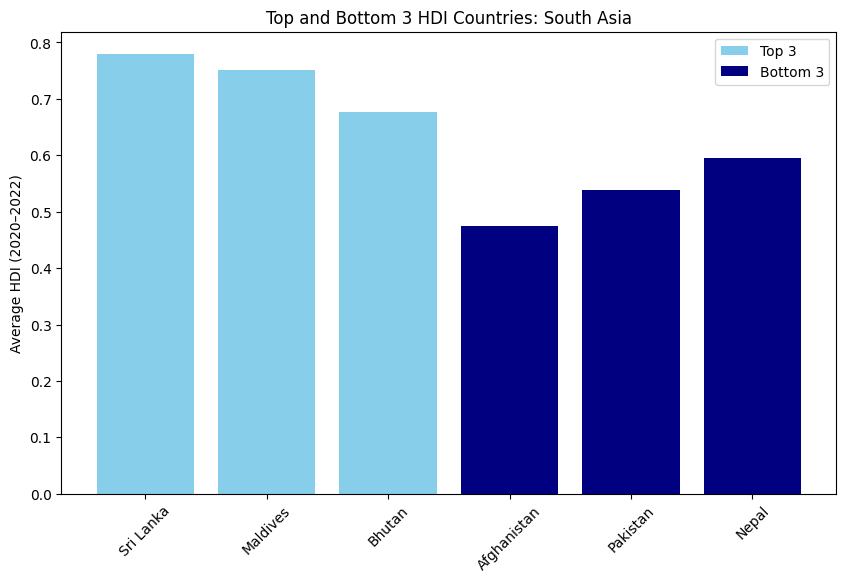

In [ ]:
top3 = southAsia_top.head(3)
bottom3 = southAsia_bottom.head(3)

plt.figure(figsize=(10,6))
plt.bar(top3.index, top3.values, color='skyblue', label='Top 3')
plt.bar(bottom3.index, bottom3.values, color='navy', label='Bottom 3')

plt.ylabel('Average HDI (2020–2022)')
plt.title('Top and Bottom 3 HDI Countries: South Asia')
plt.xticks(rotation=45)
plt.legend()
plt.savefig("Top_and_Bottom_3_HDI_South_Asia.png")
plt.show()


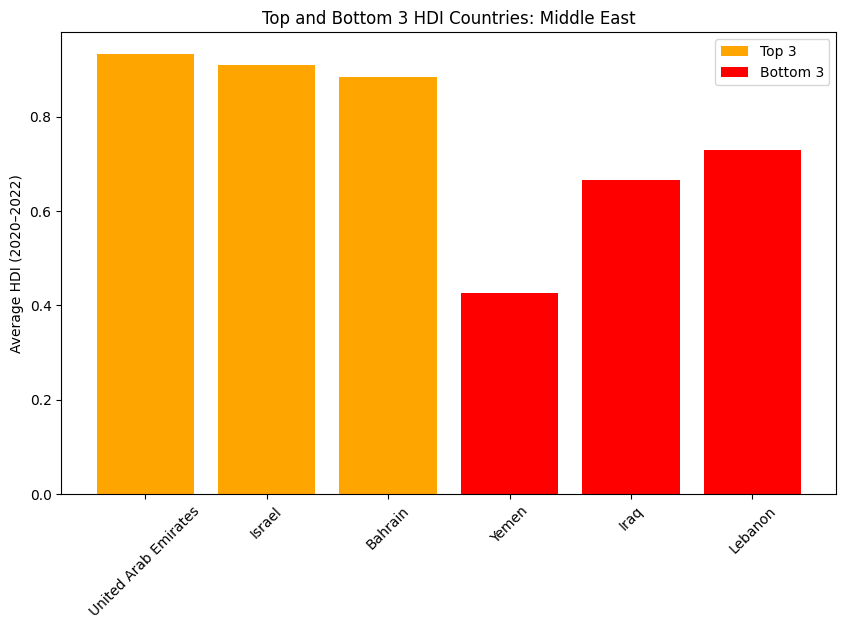

In [ ]:
top3 = middleEast_top.head(3)
bottom3 = middleEast_bottom.head(3)

plt.figure(figsize=(10,6))

# Plot top 3
plt.bar(top3.index, top3.values, color='orange', label='Top 3')
plt.bar(bottom3.index, bottom3.values, color='red', label='Bottom 3')

plt.ylabel('Average HDI (2020–2022)')
plt.title('Top and Bottom 3 HDI Countries: Middle East')
plt.xticks(rotation=45)
plt.legend()
plt.savefig("Top_and_Bottom_3_HDI_Middle_East.png")
plt.show()

4. Metric Comparisons:
• Compare the following metrics across regions using grouped bar charts:
– Gender Development Index {"gender development"}
– Life Expectancy Index {"life expectancy"}
– GNI per Capita Index {"gross inc percap"}
• Identify which metric shows the greatest disparity between regions.

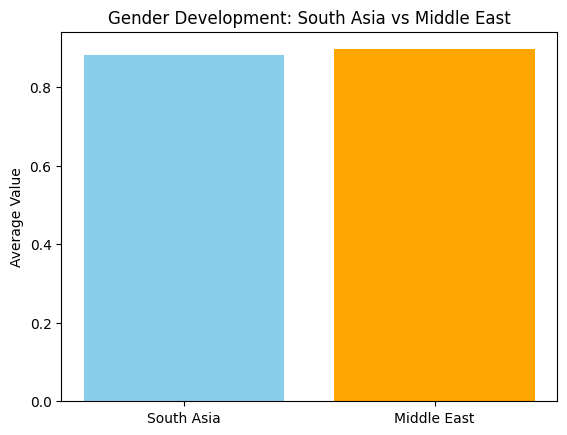

In [ ]:
# Bar plot for Gender Development
southAsia_value = southAsia_hdi["gender_development"].mean()
middleEast_value = middleEast_hdi["gender_development"].mean()

plt.bar(["South Asia", "Middle East"], [southAsia_value, middleEast_value], color=['skyblue', 'orange'])
plt.ylabel("Average Value")
plt.title("Gender Development: South Asia vs Middle East")
plt.savefig("Gender Development: South Asia vs Middle East.png")
plt.show()


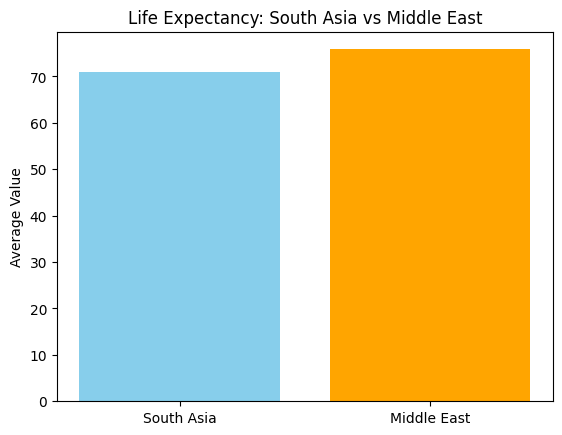

In [ ]:
#Bar plot for Life Expectancy
sothAsia_value = southAsia_hdi["life_expectancy"].mean()
middleEast_value = middleEast_hdi["life_expectancy"].mean()

plt.bar(["South Asia", "Middle East"], [sothAsia_value, middleEast_value], color=['skyblue', 'orange'])
plt.ylabel("Average Value")
plt.title("Life Expectancy: South Asia vs Middle East")
plt.show()


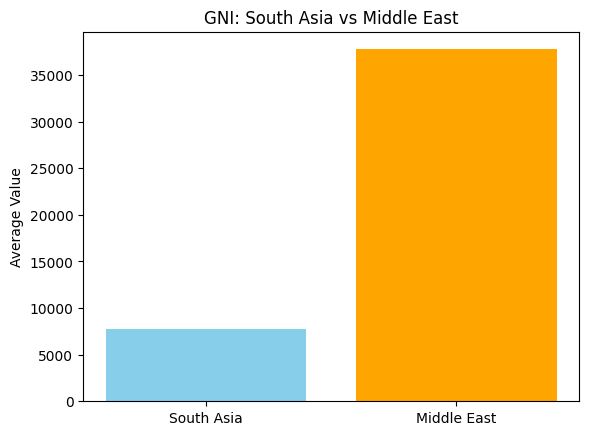

In [ ]:
#Bar Plo for Gross_inc_percap
southAsia_value = southAsia_hdi["gross_inc_percap"].mean()
middleEast_value = middleEast_hdi["gross_inc_percap"].mean()


plt.bar(["South Asia", "Middle East"], [southAsia_value, middleEast_value], color=['skyblue', 'orange'])
plt.ylabel("Average Value")
plt.title("GNI: South Asia vs Middle East")
plt.show()


GNI per Capita Index shows the greatest disparity between regions.

5. HDI Disparity:
• Compute the range (max – min) of HDI for each region.
• Compute the coefficient of variation (CV = std/mean) for HDI.
• Identify which region exhibits more variation in HDI.

In [ ]:
southAsia_range=southAsia_hdi['hdi'].max()-southAsia_hdi['hdi'].min()
southAsia_CV=southAsia_std/southAsia_mean
print("South Asia Range and CV")
print("South Asia Range:",southAsia_range)
print("South Asia CV:",southAsia_CV)

middleEast_range=middleEast_hdi['hdi'].max()-middleEast_hdi['hdi'].min()
middleEast_CV=middleEast_std/middleEast_mean
print("\nMiddle East Range and CV")
print("Middle East  Range:",middleEast_range)
print("Middle East  CV:",middleEast_CV)

if southAsia_CV > middleEast_CV:
    print("\nSouth Asia exhibits more variation in HDI.")
elif southAsia_CV < middleEast_CV:
    print("\nMiddle East exhibits more variation in HDI.")
else:
    print("\nBoth regions exhibit similar variation in HDI.")

South Asia Range and CV
South Asia Range: 0.321
South Asia CV: 0.1536520924690084

Middle East Range and CV
Middle East  Range: 0.5130000000000001
Middle East  CV: 0.17910145193048382

Middle East exhibits more variation in HDI.


6. Correlation Analysis:
• For each region, compute correlations of HDI with:
– Gender Development Index
– Life Expectancy Index
• Create scatter plots with trendlines for each correlation.
• Interpret the strength and direction of these relationships.

In [ ]:
#South Asia Correlations
print("South Asia Correlations")
print("HDI vs Gender Development:",southAsia_hdi["hdi"].corr(southAsia_hdi["gender_development"]))
print("HDI vs Life Expectancy:",southAsia_hdi["hdi"].corr(southAsia_hdi["life_expectancy"]))

#Middle East Correlations
print("\nMiddle East Correlations")
print("HDI vs Gender Development:",middleEast_hdi["hdi"].corr(middleEast_hdi["gender_development"]))
print("HDI vs Life Expectancy:",middleEast_hdi["hdi"].corr(middleEast_hdi["life_expectancy"]))


South Asia Correlations
HDI vs Gender Development: 0.8742177004831327
HDI vs Life Expectancy: 0.9387641385416623

Middle East Correlations
HDI vs Gender Development: 0.9356697525724119
HDI vs Life Expectancy: 0.9331227568940162


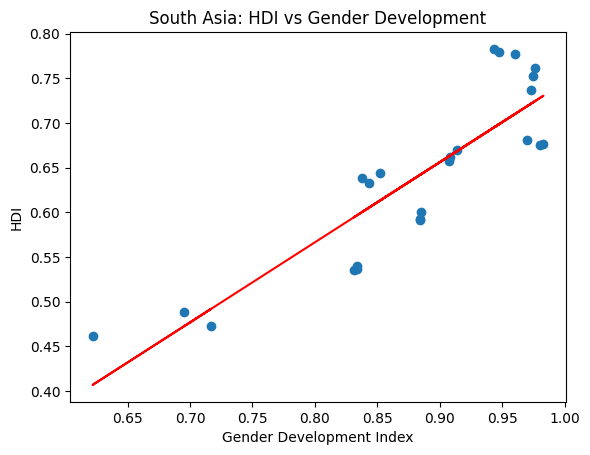

In [ ]:
#Scatter plots for SouthAsia(Gender Development Vs HDI)
plt.scatter(southAsia_hdi["gender_development"], southAsia_hdi["hdi"])
plt.xlabel("Gender Development Index")
plt.ylabel("HDI")
plt.title("South Asia: HDI vs Gender Development")
x = southAsia_hdi["gender_development"]
y = southAsia_hdi["hdi"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")
plt.savefig("Middle East: HDI vs Gender Development.png")
plt.show()


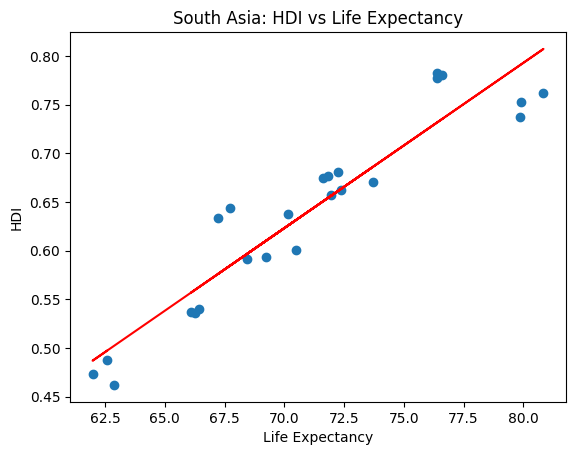

In [ ]:
#Scatter plots for SouthAsia(Life Expectancy Vs HDI)
plt.scatter(southAsia_hdi["life_expectancy"], southAsia_hdi["hdi"])
plt.xlabel("Life Expectancy")
plt.ylabel("HDI")
plt.title("South Asia: HDI vs Life Expectancy")
x = southAsia_hdi["life_expectancy"]
y = southAsia_hdi["hdi"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")
plt.savefig("Middle East: HDI vs Gender Development.png")
plt.show()

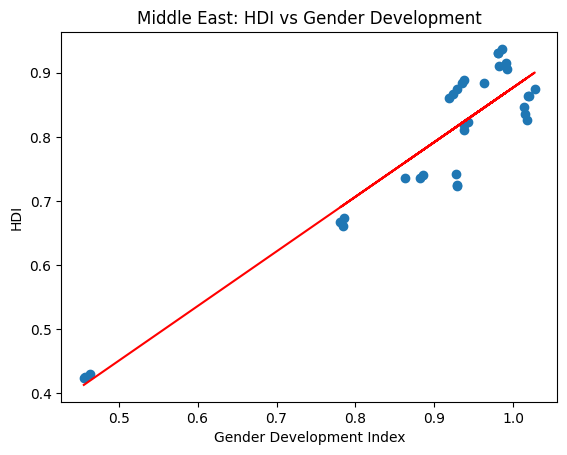

In [ ]:
#Scatter plots for MiddleEast(Gender Development Vs HDI)
plt.scatter(middleEast_hdi["gender_development"], middleEast_hdi["hdi"])
plt.xlabel("Gender Development Index")
plt.ylabel("HDI")
plt.title("Middle East: HDI vs Gender Development")
x = middleEast_hdi["gender_development"]
y = middleEast_hdi["hdi"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")
plt.savefig("Middle East: HDI vs Gender Development.png")
plt.show()

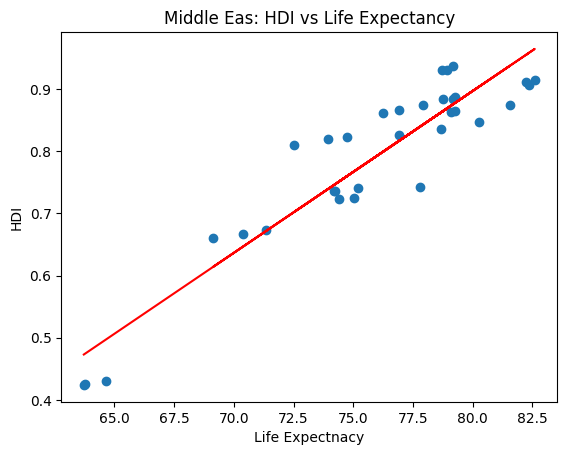

In [ ]:
#Scatter plots for MiddleEast(Life Expectancy Vs HDI)
plt.scatter(middleEast_hdi["life_expectancy"], middleEast_hdi["hdi"])
plt.xlabel("Life Expectnacy")
plt.ylabel("HDI")
plt.title("Middle Eas: HDI vs Life Expectancy")
x = middleEast_hdi["life_expectancy"]
y = middleEast_hdi["hdi"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")
plt.savefig("Middle East: HDI vs Gender Development.png")
plt.show()

7. Outlier Detection:
• Detect outliers in HDI {"hdi"} and GNI per Capita {"gross inc percap"} for each region using
the 1.5 × IQR rule.
• Create scatter plots highlighting outliers in a different color.
• Discuss the significance of these outliers.

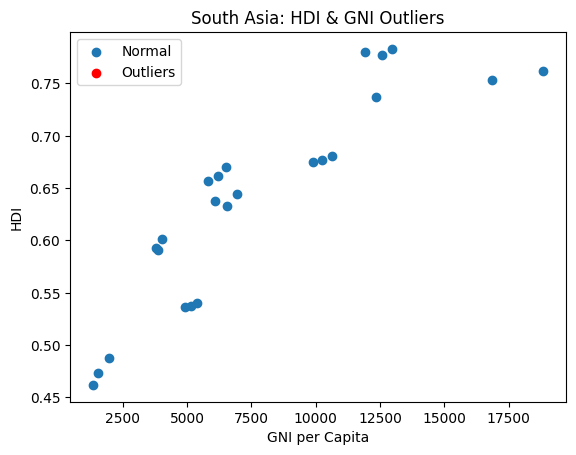

In [ ]:
#HDI Outliers
Q1_hdi = southAsia_hdi["hdi"].quantile(0.25)
Q3_hdi = southAsia_hdi["hdi"].quantile(0.75)
IQR_hdi = Q3_hdi - Q1_hdi

hdi_outliers = (
    (southAsia_hdi["hdi"] < Q1_hdi - 1.5 * IQR_hdi) |
    (southAsia_hdi["hdi"] > Q3_hdi + 1.5 * IQR_hdi)
)

Q1_gni = southAsia_hdi["gross_inc_percap"].quantile(0.25)
Q3_gni = southAsia_hdi["gross_inc_percap"].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni

#GNI Outliers
gni_outliers = (
    (southAsia_hdi["gross_inc_percap"] < Q1_gni - 1.5 * IQR_gni) |
    (southAsia_hdi["gross_inc_percap"] > Q3_gni + 1.5 * IQR_gni)
)

outliers_sa = southAsia_hdi[hdi_outliers | gni_outliers]
normal_sa = southAsia_hdi[~(hdi_outliers | gni_outliers)]

plt.figure()
plt.scatter(normal_sa["gross_inc_percap"], normal_sa["hdi"], label="Normal")
plt.scatter(outliers_sa["gross_inc_percap"], outliers_sa["hdi"], color="red", label="Outliers")

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("South Asia: HDI & GNI Outliers")
plt.legend()
plt.savefig("South_Asia_HDI_GNI_Outliers.png")
plt.show()


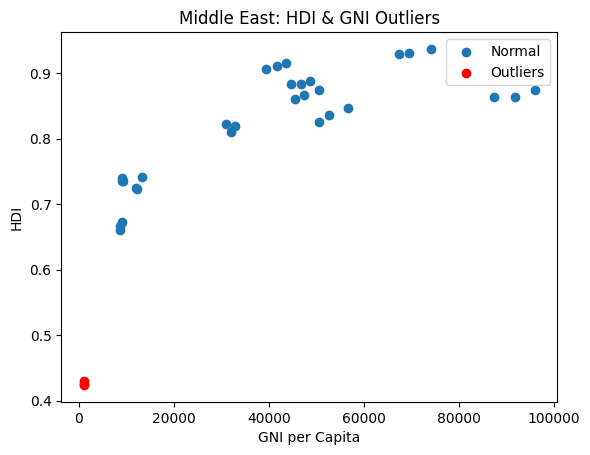

In [ ]:
#HDI Outliers
Q1_hdi = middleEast_hdi["hdi"].quantile(0.25)
Q3_hdi = middleEast_hdi["hdi"].quantile(0.75)
IQR_hdi = Q3_hdi - Q1_hdi

hdi_outliers = (
    (middleEast_hdi["hdi"] < Q1_hdi - 1.5 * IQR_hdi) |
    (middleEast_hdi["hdi"] > Q3_hdi + 1.5 * IQR_hdi)
)

#GNI Outliers
Q1_gni = middleEast_hdi["gross_inc_percap"].quantile(0.25)
Q3_gni = middleEast_hdi["gross_inc_percap"].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni

gni_outliers = (
    (middleEast_hdi["gross_inc_percap"] < Q1_gni - 1.5 * IQR_gni) |
    (middleEast_hdi["gross_inc_percap"] > Q3_gni + 1.5 * IQR_gni)
)

outliers_me = middleEast_hdi[hdi_outliers | gni_outliers]
normal_me = middleEast_hdi[~(hdi_outliers | gni_outliers)]

plt.figure()
plt.scatter(normal_me["gross_inc_percap"], normal_me["hdi"], label="Normal")
plt.scatter(outliers_me["gross_inc_percap"], outliers_me["hdi"], color="red", label="Outliers")

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("Middle East: HDI & GNI Outliers")
plt.legend()
plt.show()

